In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Load raw data
df_raw = pd.read_csv(
    '../data/raw/DataCoSupplyChainDataset.csv',
    encoding='latin-1'
)

print(f'Shape: {df_raw.shape}')
print(f'Rows: {df_raw.shape[0]:,} | Columns: {df_raw.shape[1]}')
df_raw.head(3)

Shape: (180519, 53)
Rows: 180,519 | Columns: 53


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.11,0.04,180517,327.75,0.29,1,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.09,311.36,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.00,2,Fitness,18.28,-66.04,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.39,0.05,179254,327.75,-0.80,1,327.75,311.36,-249.09,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.78,309.72,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.00,2,Fitness,37.29,-121.88,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.03,0.06,179253,327.75,-0.80,1,327.75,309.72,-247.78,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class


In [3]:
# Step 1: See all column names — identify naming inconsistencies
print('Original Column Names:')
print(df_raw.columns.to_list())

# Standardize: lowercase, underscores, no spaces
# This is mandatory for SQL compatibility

df = df_raw.copy()
df.columns = (df_raw.columns
      .str.strip()
      .str.lower()
      .str.replace(' ', '_')
      .str.replace(r'[^a-z0-9_]', '', regex = True)
)

print("\nCLEANED COLUMN NAMES:")
print(df.columns.tolist())

Original Column Names:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status', '

In [4]:
# ============================================================
# DATA TYPE AUDIT — Are dates stored as dates? Numbers as numbers?
# ============================================================

print('Data Types:')
print(df.dtypes)

print('\nNULL COUNTS (Top 20 columns with nulls):')
null_summary = df.isnull().sum()
null_summary = null_summary[null_summary > 0].sort_values(ascending = True)
print(null_summary.head(20))

print(f"\nTotal columns with nulls: {len(null_summary)}")

Data Types:
type                            object
days_for_shipping_real           int64
days_for_shipment_scheduled      int64
benefit_per_order              float64
sales_per_customer             float64
delivery_status                 object
late_delivery_risk               int64
category_id                      int64
category_name                   object
customer_city                   object
customer_country                object
customer_email                  object
customer_fname                  object
customer_id                      int64
customer_lname                  object
customer_password               object
customer_segment                object
customer_state                  object
customer_street                 object
customer_zipcode               float64
department_id                    int64
department_name                 object
latitude                       float64
longitude                      float64
market                          object
order_city   

In [5]:
# DATE PARSING

df['order_date'] = pd.to_datetime(
    df['order_date_dateorders'],
    format = '%m/%d/%Y %H:%M',
    errors = 'coerce'  # bad dates → NaT (Not a Time), not crash 
)

df['ship_date'] = pd.to_datetime(
    df['shipping_date_dateorders'],
    format = '%m/%d/%Y %H:%M',
    errors = 'coerce' 
)

print("Order Date range:")
print(f"  Min: {df['order_date'].min()}")
print(f"  Max: {df['order_date'].max()}")
print(f"  Nulls after parse: {df['order_date'].isnull().sum()}")

print("\nShip Date range:")
print(f"  Min: {df['ship_date'].min()}")
print(f"  Max: {df['ship_date'].max()}")
print(f"  Nulls after parse: {df['ship_date'].isnull().sum()}")

Order Date range:
  Min: 2015-01-01 00:00:00
  Max: 2018-01-31 23:38:00
  Nulls after parse: 0

Ship Date range:
  Min: 2015-01-03 00:00:00
  Max: 2018-02-06 22:14:00
  Nulls after parse: 0


In [6]:
# MISSING VALUE TREATMENT

# 1. Drop columns with > 50% nulls (not salvageable for analysis)

high_null_cols = null_summary[null_summary/len(df) > 0.5].index.to_list()
print(f"Dropping high-null columns: {high_null_cols}")
df.drop(columns=high_null_cols, inplace=True)

# 2. Drop PII columns (Customer email, name — not needed for analytics)

pii_cols = ['customer_email', 'customer_fname', 'customer_lname',
            'customer_password', 'product_image', 'product_description']
pii_cols_present = [c for c in pii_cols if c in df.columns]
df.drop(columns = pii_cols_present, inplace = True)
print(f"Dropped PII columns: {  pii_cols_present}")

# 3. Fill missing product prices with median (by category)
# Business reason: product price shouldn't be null; 
# median is more robust than mean (resistant to outliers)

if 'product_price' in df.columns:
    df['product_price'] = df.groupby('category_name')['product_price'].transform(
        lambda x:x.fillna(x.median())
    )
    print(f"Remaining product_price nulls: {df['product_price'].isnull().sum()}")


# 4. Fill remaining numeric nulls with 0 (quantities, profits)

numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].fillna(0)

print(f"\nShape after cleaning: {df.shape}")
print(f"Remaining nulls: {df.isnull().sum().sum()}")

Dropping high-null columns: ['order_zipcode', 'product_description']
Dropped PII columns: ['customer_email', 'customer_fname', 'customer_lname', 'customer_password', 'product_image']
Remaining product_price nulls: 0

Shape after cleaning: (180519, 48)
Remaining nulls: 0


In [7]:
# DUPLICATE DETECTION
# Check for duplicate order-item combinations

duplicate_check = df.duplicated(
    subset=['order_id', 'order_item_id'],
    keep = False
)
print(f'Duplicate order-item rows: {duplicate_check.sum()}')

# Remove exact duplicates
df.drop_duplicates(subset=['order_id', 'order_item_id'], keep='first', inplace=True)
print(f"Shape after dedup: {df.shape}")

Duplicate order-item rows: 0
Shape after dedup: (180519, 48)


In [8]:
# FEATURE ENGINEERING — delay_days (THE most important column)
# 
# Business Logic:
#   - days_for_shipping_real = how long it actually took
#   - days_for_shipment_scheduled = how long it was promised
#   - delay_days = actual - scheduled
#   - Positive = late | Zero = on-time | Negative = early

df['delay_days'] = df['days_for_shipping_real'] - df['days_for_shipment_scheduled']

# Sanity check
print("delay_days distribution:")
print(df['delay_days'].describe())
print(f"\nOn-time or early (delay <= 0): {(df['delay_days'] <= 0).sum():,}")
print(f"Late (delay > 0):              {(df['delay_days'] > 0).sum():,}")
print(f"Late %:                         {(df['delay_days'] > 0).mean() * 100:.1f}%")

delay_days distribution:
count   180519.00
mean         0.57
std          1.49
min         -2.00
25%          0.00
50%          1.00
75%          1.00
max          4.00
Name: delay_days, dtype: float64

On-time or early (delay <= 0): 77,119
Late (delay > 0):              103,400
Late %:                         57.3%


In [9]:
# CLEAN CATEGORICALS — Remove whitespace, standardize casing

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

# Verify delivery status values
print("Delivery Status values:")
print(df['delivery_status'].value_counts())

print("\nShipping Mode values:")
print(df['shipping_mode'].value_counts())

print("\nCustomer Segment values:")
print(df['customer_segment'].value_counts())

print("\nMarket values:")
print(df['market'].value_counts())

Delivery Status values:
delivery_status
Late Delivery        98977
Advance Shipping     41592
Shipping On Time     32196
Shipping Canceled     7754
Name: count, dtype: int64

Shipping Mode values:
shipping_mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

Customer Segment values:
customer_segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64

Market values:
market
Latam           51594
Europe          50252
Pacific Asia    41260
Usca            25799
Africa          11614
Name: count, dtype: int64


In [10]:
# SANITY CHECKS — Would a business user trust this data?

# Check 1: Negative profits should exist (loss-making orders — valid in supply chain)
print(f"Orders with negative profit: {(df['order_profit_per_order'] < 0).sum():,}")
print(f"Total profit: ${df['order_profit_per_order'].sum():,.0f}")

# Check 2: Sales should be positive
neg_sales = (df['sales_per_customer'] < 0).sum()
print(f"\nOrders with negative sales: {neg_sales}")
if neg_sales > 0:
    # These are likely returns/cancellations — flag, don't delete
    df['is_return'] = (df['sales_per_customer'] < 0).astype(int)

# Check 3: Date logic — ship date should not be before order date
bad_dates = (df['ship_date'] < df['order_date']).sum()
print(f"\nRows where ship_date < order_date: {bad_dates}")
# If > 0: filter these out as data entry errors
df = df[df['ship_date'] >= df['order_date']]
print(f"Shape after date logic fix: {df.shape}")

Orders with negative profit: 33,784
Total profit: $3,966,903

Orders with negative sales: 0

Rows where ship_date < order_date: 0
Shape after date logic fix: (180519, 49)


In [11]:
# EXPORT — Save cleaned master + dimensional tables

os.makedirs('../data/cleaned', exist_ok=True)

# ─── MASTER ───────────────────
df.to_csv('../data/cleaned/supply_chain_master.csv', index=False)
print(f"✅ Master saved: {df.shape}")

# ─── FACT TABLE ─────────────────────────────────────────────
# ─── FACT TABLE ─────────────────────────────────────────────
fact_cols = [
    'order_id', 'order_item_id', 'customer_id', 'product_card_id',
    'order_date', 'ship_date', 'shipping_mode',
    'order_item_quantity', 'sales_per_customer',
    'order_profit_per_order', 'order_item_total',
    'days_for_shipping_real', 'days_for_shipment_scheduled',
    'delay_days', 'late_delivery_risk', 'delivery_status',
    'market', 'order_region', 'order_country'
]
fact_cols_present = [c for c in fact_cols if c in df.columns]
fact_orders = df[fact_cols_present].copy()
fact_orders.to_csv('../data/cleaned/fact_orders.csv', index=False)
print(f"✅ Fact table saved: {fact_orders.shape}")

# ─── DIM: CUSTOMER ──────────────────────────────────────────
dim_customer = df[[
    'customer_id', 'customer_segment',
    'customer_city', 'customer_state', 'customer_country'
]].drop_duplicates(subset='customer_id').reset_index(drop=True)
dim_customer.to_csv('../data/cleaned/dim_customer.csv', index=False)
print(f"✅ dim_customer saved: {dim_customer.shape}")

# ─── DIM: PRODUCT ───────────────────────────────────────────
dim_product = df[[
    'product_card_id', 'product_name', 'category_name',
    'department_name', 'product_price'
]].drop_duplicates(subset='product_card_id').reset_index(drop=True)
dim_product.to_csv('../data/cleaned/dim_product.csv', index=False)
print(f"✅ dim_product saved: {dim_product.shape}")

# ─── DIM: GEOGRAPHY ─────────────────────────────────────────
dim_geo = df[[
    'market', 'order_region', 'order_country', 'order_city', 'order_state'
]].drop_duplicates().reset_index(drop=True)
dim_geo['geo_id'] = range(1, len(dim_geo) + 1)
dim_geo.to_csv('../data/cleaned/dim_geo.csv', index=False)
print(f"✅ dim_geo saved: {dim_geo.shape}")

# ─── DIM: DATE ──────────────────────────────────────────────
# Generate a complete date dimension — this powers all time intelligence
all_dates = pd.date_range(
    start=df['order_date'].min(),
    end=df['order_date'].max(),
    freq='D'
)

dim_date = pd.DataFrame({'order_date': all_dates})
dim_date['date_id']       = dim_date['order_date'].dt.strftime('%Y%m%d').astype(int)
dim_date['year']             = dim_date['order_date'].dt.year
dim_date['quarter']       = dim_date['order_date'].dt.quarter
dim_date['month_num']     = dim_date['order_date'].dt.month
dim_date['month_name']    = dim_date['order_date'].dt.strftime('%B')
dim_date['week']          = dim_date['order_date'].dt.isocalendar().week
dim_date['day_of_week']   = dim_date['order_date'].dt.day_name()
dim_date['is_weekend']    = dim_date['order_date'].dt.dayofweek >= 5

dim_date.to_csv('../data/cleaned/dim_date.csv', index=False)
print(f"✅ dim_date saved: {dim_date.shape}")

✅ Master saved: (180519, 49)
✅ Fact table saved: (180519, 19)
✅ dim_customer saved: (20652, 5)
✅ dim_product saved: (118, 5)
✅ dim_geo saved: (3772, 6)
✅ dim_date saved: (1127, 9)


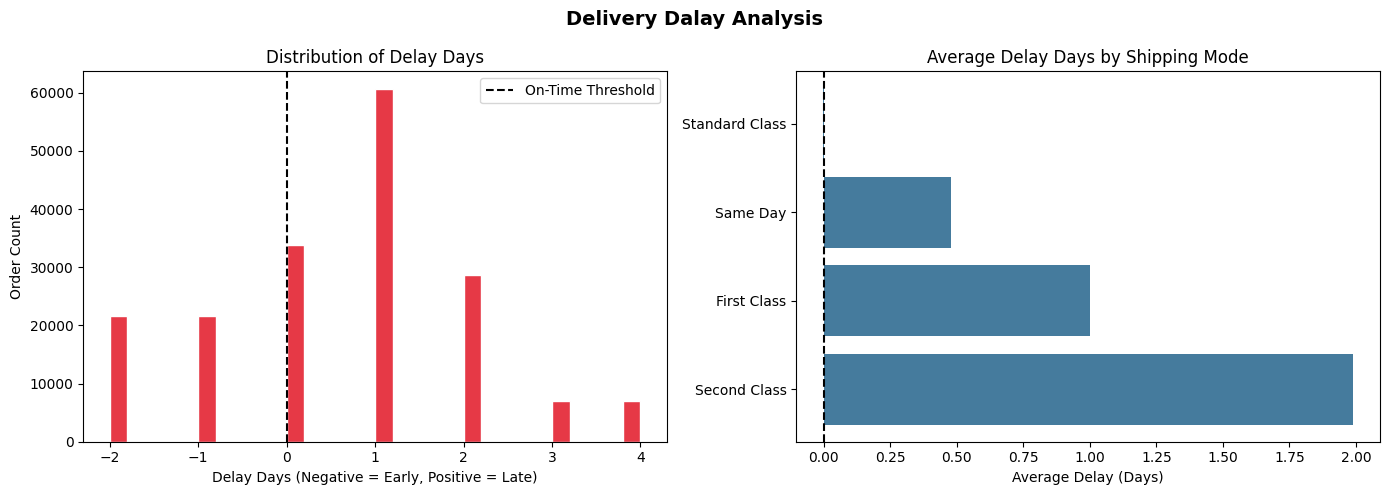

Chart saved.


In [14]:
# EDA: Understand the shape of our target variable

fig, axes = plt.subplots(1,2, figsize = (14,5))
fig.suptitle('Delivery Dalay Analysis', fontsize = 14, fontweight = 'bold')

# Distribution
axes[0].hist(df['delay_days'], bins = 30, color = '#E63946', edgecolor = 'white')
axes[0].set_title('Distribution of Delay Days')
axes[0].set_xlabel('Delay Days (Negative = Early, Positive = Late)')
axes[0].set_ylabel('Order Count')
axes[0].axvline(0, color='black', linestyle='--', label='On-Time Threshold')
axes[0].legend()

# By shipping mode
delay_by_mode = df.groupby('shipping_mode')['delay_days'].mean().sort_values(ascending=False)
axes[1].barh(delay_by_mode.index, delay_by_mode.values, color='#457B9D')
axes[1].set_title('Average Delay Days by Shipping Mode')
axes[1].set_xlabel('Average Delay (Days)')
axes[1].axvline(0, color='black', linestyle='--')

plt.tight_layout()
plt.savefig('../docs/eda_delay_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

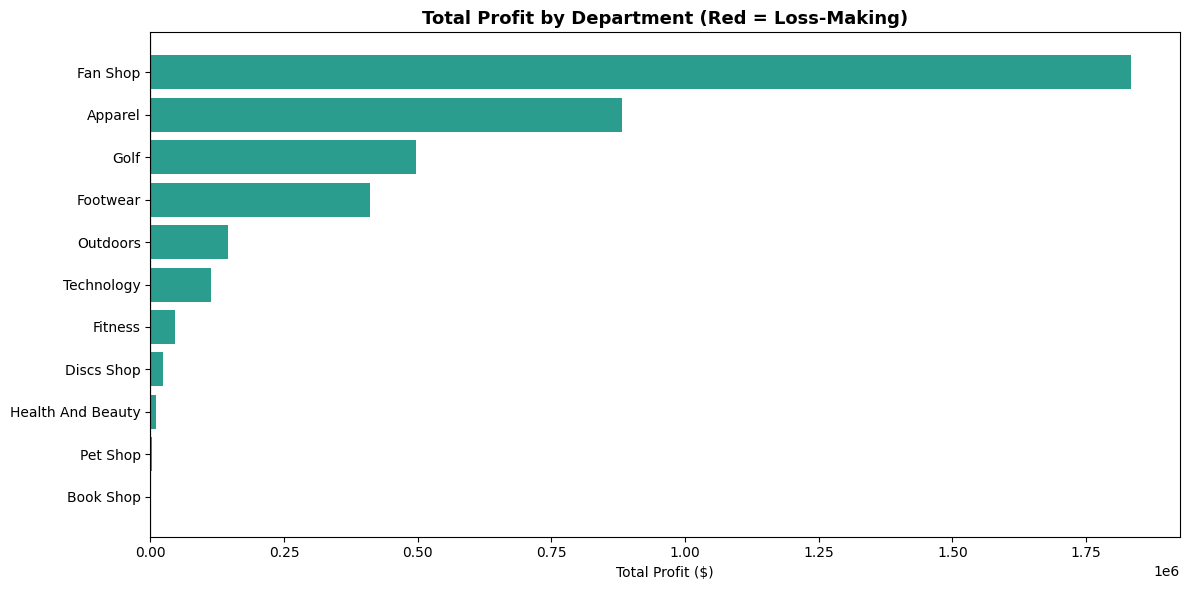

In [18]:
# EDA: Which departments are profitable vs loss-making?

dept_profit = df.groupby('department_name')['order_profit_per_order'].sum().sort_values().reset_index()

colors = ['#E63946' if x < 0 else '#2A9D8F' for x in dept_profit['order_profit_per_order']]

plt.figure(figsize = (12,6))
bars = plt.barh(
    dept_profit['department_name'],
    dept_profit['order_profit_per_order'],
    color = colors
)

plt.axvline(0, color = 'black', linewidth = 0.8)
plt.title('Total Profit by Department (Red = Loss-Making)', fontsize = 13, fontweight = 'bold')
plt.xlabel('Total Profit ($)')
plt.tight_layout()
plt.savefig('../docs/eda_dept_profit.png', dpi=150, bbox_inches='tight')
plt.show()

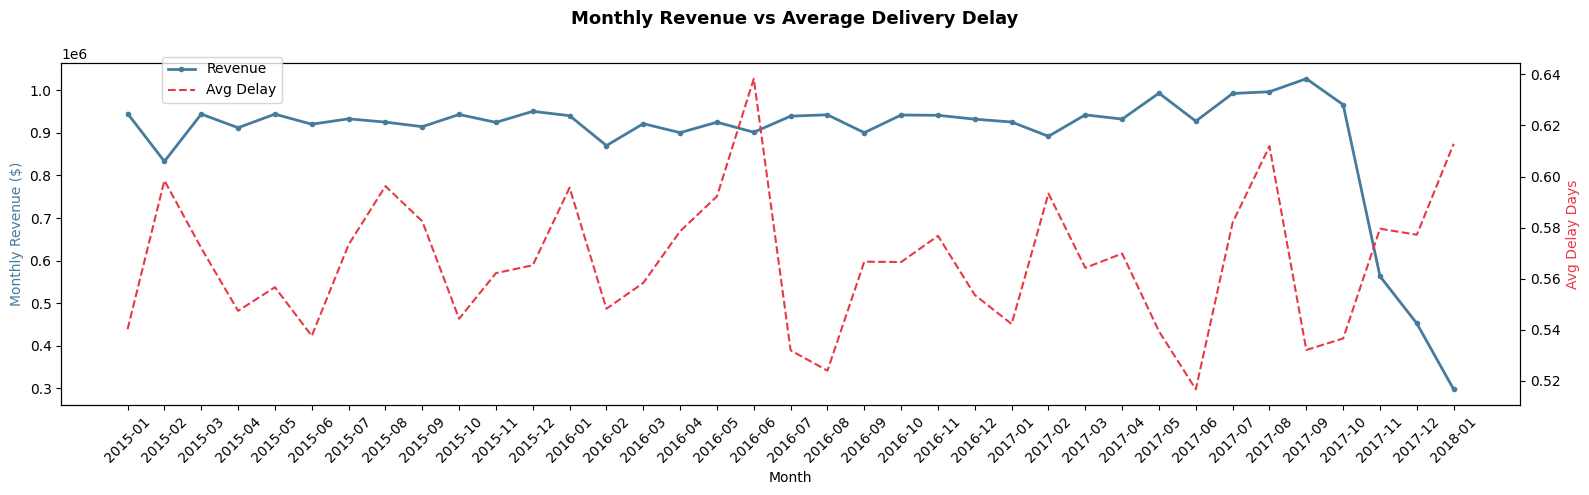

In [20]:
# EDA: Revenue trend over time

df['year_month'] = df['order_date'].dt.to_period('M')
monthly = df.groupby('year_month').agg(revenue = ('sales_per_customer', 'sum'),
                                       orders = ('order_id', 'nunique'),
                                       avg_delay = ('delay_days', 'mean')).reset_index()
monthly['year_month_str'] = monthly['year_month'].astype(str)

fig, ax1 = plt.subplots(figsize = (16,5))
ax1.plot(monthly['year_month_str'], monthly['revenue'],
         color = '#457B9D', linewidth = 2, marker = 'o', markersize = 3, label = 'Revenue')
ax1.set_xlabel('Month')
ax1.set_ylabel('Monthly Revenue ($)', color = '#457B9D')
ax1.tick_params(axis = 'x', rotation = 45)

ax2 = ax1.twinx()
ax2.plot(monthly['year_month_str'], monthly['avg_delay'],
         color = '#E63946', linewidth = 1.5, linestyle = '--', label = 'Avg Delay')
ax2.set_ylabel('Avg Delay Days', color = '#E63946')

fig.suptitle('Monthly Revenue vs Average Delivery Delay', fontsize=13, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.savefig('../docs/eda_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

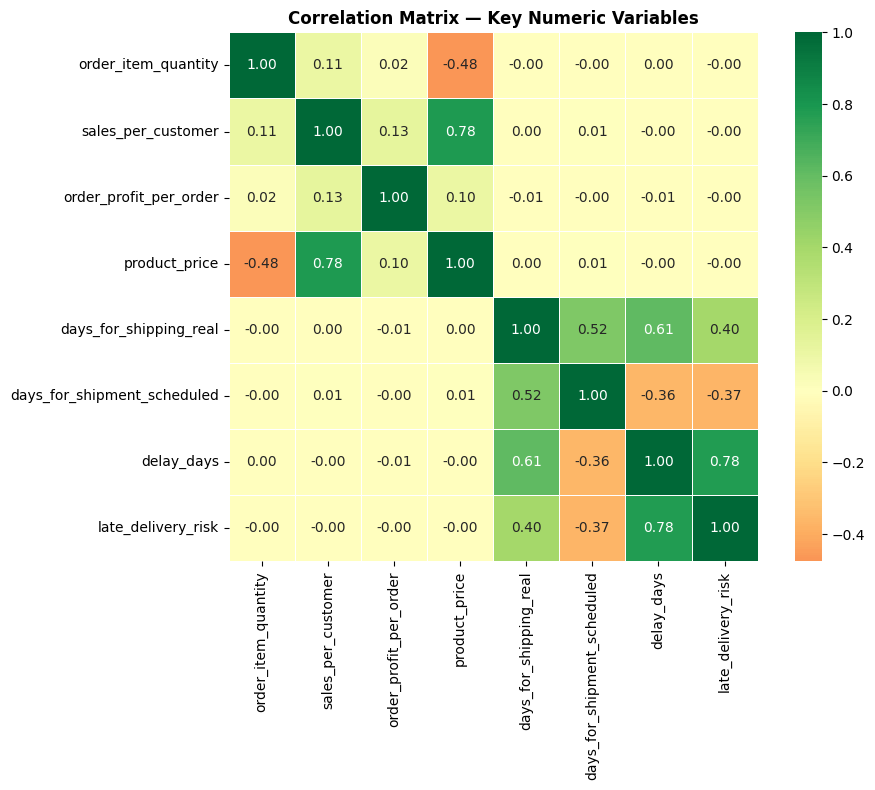

In [22]:
# EDA: Which numeric variables correlate with delay_days?

numeric_features = [
    'order_item_quantity', 'sales_per_customer',
    'order_profit_per_order', 'product_price',
    'days_for_shipping_real', 'days_for_shipment_scheduled',
    'delay_days', 'late_delivery_risk'
]
numeric_features = [c for c in numeric_features if c in df.columns]

corr_matric = df[numeric_features].corr()

plt.figure(figsize = (10,8))
sns.heatmap(
    corr_matric,
    annot = True, fmt = '.2f',
    cmap = 'RdYlGn', center = 0,
    linewidths=0.5,
    square=True
)

plt.title('Correlation Matrix — Key Numeric Variables', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()